# NFL QBR Regression Analysis

* This is a blank notebook, you can create a new notebook or use this one.
* Whichever option you choose, make sure you clearly name the notebook so peers know this is your project
* Any blank/unused notebooks in your workarea should be removed

Link for more information: https://cse6040.gatech.edu/active/Assignments%20%2B%20Exams/extra_credit/

Within this notebook, we will be exploring the NFL Quarterback Index from Kaggle (https://www.kaggle.com/datasets/datadraco/nfl-quarterback-index). The main question we want to answer is, given a quarterback's college stats, can we 1. predict NFL QBR as an indication of success using linear regression?

Previously, similar projects have indicated that there is weak predictiveness of NFL success with just college statistics and draft factors, and this notebook aims to either prove or disprove this analysis.

First, let's import the packages we need for this analysis and our dataset as 'nfl_df', reading the NFL Quarterback Index as a csv file.

In [3]:
import re
import pandas as pd
import sklearn as sk
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from time import time
from pprint import pprint

/usr/local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
/usr/local/lib/python3.8/site-packages/statsmodels/tsa/base/tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


In [4]:
nfl_df = pd.read_csv('qb_index_no_tier.csv')

In [5]:
display(nfl_df.head())
display(nfl_df.tail())

,year-drafted,qb-num-picked,rd-picked,num-picked,name,height (in),weight (lbs),nfl-team,coach-tenure,drafted-team-winpr,...,nfl-int%,nfl-sack%,nfl-y/a,nfl-ay/a,nfl-any/a,nfl-y/c,nfl-y/g,nfl-succ%,nfl-4qc,nfl-gwd
0,2023,1,1,1,Bryce Young,70,204,Panthers,0,0.412,...,1.9,10.53,5.5,5.02,3.68,9.1,179.8,36.5,2,2
1,2023,2,1,2,C.J. Stroud,75,214,Texans,0,0.206,...,1.0,7.08,8.2,8.70,7.47,12.9,273.9,46.7,1,3
2,2023,3,1,4,Anthony Richardson,76,244,Colts,0,0.265,...,1.2,7.69,6.9,7.05,6.19,11.5,144.3,44.0,0,0
3,2023,4,2,33,Will Levis,75,229,Titans,5,0.412,...,1.6,9.89,7.1,7.01,5.66,12.1,200.9,37.1,1,1
4,2023,5,3,68,Hendon Hooker,76,217,Lions,2,0.529,...,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0,0


,year-drafted,qb-num-picked,rd-picked,num-picked,name,height (in),weight (lbs),nfl-team,coach-tenure,drafted-team-winpr,...,nfl-int%,nfl-sack%,nfl-y/a,nfl-ay/a,nfl-any/a,nfl-y/c,nfl-y/g,nfl-succ%,nfl-4qc,nfl-gwd
287,2000,8,6,202,Todd Husak,75,216,Redskins,0,0.625,...,0.0,0.00,-1.0,-1.00,-1.00,-1.0,-2.0,0.0,0,0
288,2000,9,6,205,JaJuan Seider,73,230,Chargers,1,0.500,...,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0,0
289,2000,10,7,212,Tim Rattay,72,215,49ers,3,0.250,...,3.2,8.11,6.8,6.22,5.23,11.2,121.3,43.8,1,1
290,2000,11,7,214,Jarious Jackson,72,226,Broncos,5,0.375,...,4.5,8.33,5.2,3.14,2.42,10.4,22.8,37.5,0,0
291,2000,12,7,234,Joe Hamilton,70,192,Buccaneers,4,0.688,...,0.0,100.00,0.0,0.00,-1.00,0.0,0.0,0.0,0,0


Now, let's extract some summary statistics from the QB dataset. We see that there's quite a few predictors and that specifically nfl-y/g, which indicates the yard per game a QB throws for, is unlike the rest of the predictors in terms of scale.

In [6]:
nfl_df.describe()

,year-drafted,qb-num-picked,rd-picked,num-picked,height (in),weight (lbs),coach-tenure,drafted-team-winpr,drafted_team_ppg_rk,conf-str,...,nfl-int%,nfl-sack%,nfl-y/a,nfl-ay/a,nfl-any/a,nfl-y/c,nfl-y/g,nfl-succ%,nfl-4qc,nfl-gwd
count,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.00000,292.000000,292.000000,292.000000,...,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,2011.023973,6.818493,3.941781,117.664384,75.027397,222.065068,3.10274,0.469024,16.715753,0.533548,...,2.782877,6.219658,4.783219,3.982295,3.301678,8.063014,102.797603,29.669863,3.681507,4.750000
std,6.924441,3.866048,2.177683,81.050769,1.694727,11.164771,3.83012,0.205703,8.564172,0.178099,...,3.524716,7.584808,3.544595,3.741799,3.485864,5.236188,88.459053,19.463484,7.380987,9.485158
min,2000.000000,1.000000,1.000000,1.000000,70.000000,191.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-9.000000,-9.000000,-1.000000,-2.000000,0.000000,0.000000,0.000000
25%,2005.000000,4.000000,2.000000,36.000000,74.000000,215.000000,0.00000,0.313000,10.000000,0.487750,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2011.000000,7.000000,4.000000,122.000000,75.000000,222.000000,2.00000,0.438000,18.000000,0.599000,...,2.500000,6.210000,6.100000,4.995000,4.090000,10.500000,103.100000,38.350000,0.000000,0.000000
75%,2017.000000,10.000000,6.000000,189.500000,76.000000,229.000000,4.00000,0.625000,24.000000,0.632750,...,3.400000,8.330000,6.825000,6.282500,5.432500,11.400000,175.525000,42.800000,4.000000,5.000000
max,2023.000000,17.000000,7.000000,262.000000,79.000000,265.000000,22.00000,1.000000,32.000000,0.722000,...,33.300000,100.000000,37.000000,37.000000,37.000000,37.000000,296.100000,100.000000,46.000000,58.000000


Let's also visualize the distribution of nfl-qbr so we understand how QBR is spread out across our 292 quarterbacks.

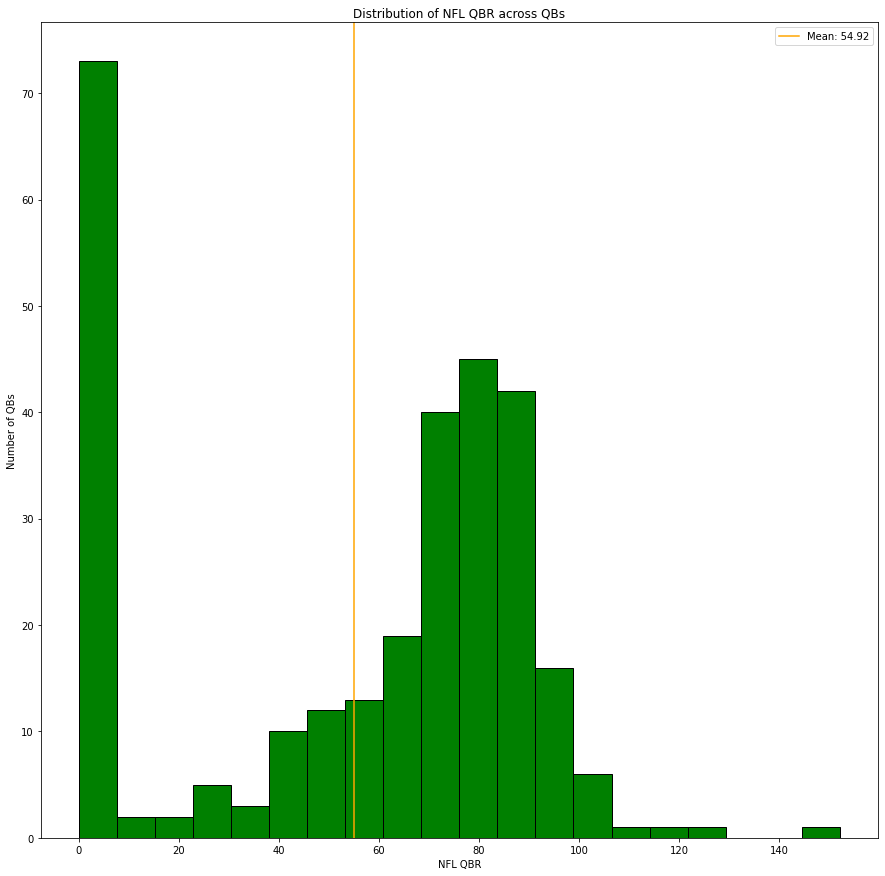

In [25]:
plt.figure(figsize=(15,15))
plt.hist(nfl_df['nfl-qbr'], bins=20, color='green', edgecolor='black')
plt.xlabel('NFL QBR')
plt.ylabel('Number of QBs')
plt.title('Distribution of NFL QBR across QBs')
plt.axvline(nfl_df['nfl-qbr'].mean(), color='orange', label=f"Mean: {nfl_df['nfl-qbr'].mean():.2f}")
plt.legend()
plt.show()

We can see in the above chart that our dataset is heavily skewed with NFL QBRs of 0, which may be reason to remove those QBs from the dataset with 0 QBRs for better success prediction. However, for the sake of this analysis, let's keep those data points in as they do reflect the reality of many drafted QBs not playing in the league. 

We have a lot of stats in here, particularly NFL level stats we don't need. We can condense down our dataframe by removing those columns.

In [8]:
clean_nfl_df = nfl_df.copy()
clean_nfl_df = clean_nfl_df.drop(['name','year-drafted', 'height (in)', 'weight (lbs)',
                                  'drafted-team-winpr', 'drafted_team_ppg_rk',
                                  'qb-num-picked','rd-picked','num-picked', 'college',
                                  'conf','conf-str','p-cmp', 'p-att','nfl-team', 'coach-tenure','nfl-starts', 'nfl-wins',
                                 'nfl-losses', 'nfl-ties', 'nfl-winpr', 'nfl-cmp', 'nfl-att', 'nfl-inc'
                                ,'nfl-comp%', 'nfl-yds', 'nfl-tds', 'nfl-int', 'nfl-pick6','nfl-int%', 'nfl-sack%',
                                'nfl-y/a', 'nfl-ay/a', 'nfl-any/a', 'nfl-y/c', 'nfl-y/g', 'nfl-succ%', 'nfl-4qc',
                                'nfl-gwd'], axis=1)

In [9]:
display(clean_nfl_df)

,cmp-pct,p-yds,p-ypa,p-adj-ypa,p-td,int,rate,r-att,r-yds,r-avg,r-tds,nfl-qbr
0,65.8,8356,8.8,9.9,80,12,165.0,139,162,1.2,7,73.7
1,69.3,8123,9.8,11.2,85,12,182.4,80,136,1.7,1,100.8
2,54.7,3105,7.9,7.4,24,15,133.6,161,1116,6.9,12,87.3
3,64.9,5876,8.0,7.7,46,25,145.6,312,742,2.4,17,84.2
4,67.0,8974,9.5,10.6,80,12,172.4,518,2083,4.0,25,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
287,53.3,6564,7.5,7.2,41,24,126.6,99,-136,-1.4,3,79.2
288,0.0,0,0.0,0.0,0,0,0.0,0,0,0.0,0,0.0
289,65.4,12746,8.2,8.7,115,35,154.3,153,-103,-0.7,2,81.9
290,57.1,4820,9.0,8.5,34,21,145.7,272,957,3.5,13,46.4


Now that we've removed the NFL level stats, let's just double-check that there are no missing values in our dataset we need to account for.

In [10]:
clean_nfl_df.isna().any(axis=None)

False

Great, we don't have any NA/missing values so now we can split our dataframe into training and testing sets.

In [11]:
nflqb_train = clean_nfl_df.sample(frac=0.8, random_state=555)
nflqb_test = clean_nfl_df.drop(nflqb_train.index)

Now that we have our training and testing sets, we can fit a linear regression model on the training set first. We will want to first store the predictors as a separate 'x' variable and then the QBR variable as 'y' for the linear regression model.

In [13]:
x_train = nflqb_train.iloc[:, :-1].values #stores all the predictors
y_train = nflqb_train.iloc[:, -1].values #stores the NFL QBR value

#Repeat the same for test set
x_test = nflqb_test.iloc[:, :-1].values 
y_test = nflqb_test.iloc[:, -1].values

In [14]:
from sklearn.linear_model import LinearRegression
qb_lin_reg_mod = LinearRegression()
train_fit = qb_lin_reg_mod.fit(x_train, y_train)

In [15]:
#Map predictions and name back to dataframe
nflqb_train['Predictions'] = train_fit.predict(x_train)
nflqb_train['Name'] = nfl_df.loc[nflqb_train.index, 'name']

nflqb_test['Predictions'] = train_fit.predict(x_test)
nflqb_test['Name'] = nfl_df.loc[nflqb_test.index, 'name']

display(nflqb_train.head(), nflqb_test.head())

,cmp-pct,p-yds,p-ypa,p-adj-ypa,p-td,int,rate,r-att,r-yds,r-avg,r-tds,nfl-qbr,Predictions,Name
147,66.3,5691,8.6,9.2,39,10,155.4,114,71,0.6,2,79.2,64.733958,Greg McElroy
103,66.7,12843,7.9,8.6,113,24,152.8,164,190,1.2,5,92.3,71.334380,Derek Carr
183,61.9,9360,7.3,7.7,79,25,139.9,232,-490,-2.1,5,0.0,61.776192,Andre' Woodson
70,67.4,10168,8.4,8.7,90,32,157.5,435,1934,4.4,26,100.8,62.916697,Deshaun Watson
117,64.1,12327,7.9,8.0,116,48,148.7,132,-113,-0.9,6,66.6,58.843973,Matt Barkley


,cmp-pct,p-yds,p-ypa,p-adj-ypa,p-td,int,rate,r-att,r-yds,r-avg,r-tds,nfl-qbr,Predictions,Name
4,67.0,8974,9.5,10.6,80,12,172.4,518,2083,4.0,25,0.0,70.200005,Hendon Hooker
13,60.3,9618,7.9,8.0,73,28,141.4,488,1856,3.8,28,0.0,58.931011,Max Duggan
17,67.3,8287,9.1,9.2,57,23,159.2,334,1338,4.0,18,0.0,61.867064,Matt Corral
20,67.7,12170,8.3,8.4,81,33,151.1,365,1177,3.2,19,111.4,62.159846,Brock Purdy
27,59.0,9661,7.1,7.3,71,27,132.0,438,1608,3.7,22,70.1,59.524212,Kellen Mond


In [28]:
from sklearn.metrics import r2_score
train_rsq = r2_score(y_train, nflqb_train['Predictions'])
test_rsq = r2_score(y_test, nflqb_test['Predictions'])
display(train_rsq)
display(test_rsq)

0.07933511847315278

-0.015476962404103567

It looks like college stats don't necessarily predict/determine NFL success (measured as QBR) all that well. From the above linear regression, we receive an R-Squared value of 0.079 on the training set, which means that only 8% of the variance in the data is explained by this model. The test set performed even worse, and shows us that linear regression on solely college stats is worse than predicting against the mean. Let's see what college metrics are of note to include, based on statistical significance:

Note: The below code is referenced from: https://stackoverflow.com/questions/58882719/how-to-predict-data-using-linearregression-using-linear-model-ols-from-statsmode

In [26]:
x2 = sm.add_constant(x_train)
est = sm.OLS(y_train, x2)
est2 = est.fit()
print(est2.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     1.739
Date:                Tue, 28 Apr 2026   Prob (F-statistic):             0.0663
Time:                        17:25:08   Log-Likelihood:                -1157.4
No. Observations:                 234   AIC:                             2339.
Df Residuals:                     222   BIC:                             2380.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.5606      8.545      4.396      0.0

Let's also view the actual vs. predicted values visually for the training set. We should see that a lot of the points are not near the linear model line.

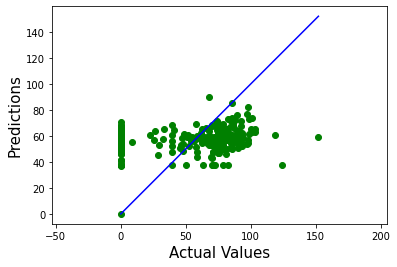

In [18]:
qbract1 = nflqb_train['nfl-qbr']
qbrpred1 = nflqb_train['Predictions']

plt.scatter(qbract1, qbrpred1, c='green')

p1 = max(max(qbrpred1), max(qbract1))
p2 = min(min(qbrpred1), min(qbract1))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('Actual Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()

Based on the statistically significant predictors, there are no predictors with a p < 0.05, however, x1 (cmp-pct), which indicates completion percentage and x4 (p-adj-ypa), passing yards adjusted are the closest to having a p < 0.05. Let's try a different set of predictors.

In [19]:
new_nfl_df = nfl_df.copy()
new_nfl_df = new_nfl_df.drop(['name','p-cmp', 'p-att','height (in)', 'weight (lbs)',
                                  'p-yds', 'p-ypa',
                                  'p-td','p-td','int', 'college',
                                  'conf','int','rate', 'r-att','nfl-team', 'r-yds', 'r-avg', 
                                'r-tds','nfl-starts', 'nfl-wins',
                                 'nfl-losses', 'nfl-ties', 'nfl-winpr', 'nfl-cmp', 'nfl-att', 'nfl-inc'
                                ,'nfl-comp%', 'nfl-yds', 'nfl-tds', 'nfl-int', 'nfl-pick6','nfl-int%', 'nfl-sack%',
                                'nfl-y/a', 'nfl-ay/a', 'nfl-any/a', 'nfl-y/c', 'nfl-y/g', 'nfl-succ%', 'nfl-4qc',
                                'nfl-gwd', 'year-drafted'], axis=1)
display(new_nfl_df)

,qb-num-picked,rd-picked,num-picked,coach-tenure,drafted-team-winpr,drafted_team_ppg_rk,conf-str,cmp-pct,p-adj-ypa,nfl-qbr
0,1,1,1,0,0.412,19,0.692,65.8,9.9,73.7
1,2,1,2,0,0.206,29,0.608,69.3,11.2,100.8
2,3,1,4,0,0.265,29,0.692,54.7,7.4,87.3
3,4,2,33,5,0.412,27,0.692,64.9,7.7,84.2
4,5,3,68,2,0.529,5,0.692,67.0,10.6,0.0
...,...,...,...,...,...,...,...,...,...,...
287,8,6,202,0,0.625,2,0.560,53.3,7.2,79.2
288,9,6,205,1,0.500,25,0.000,0.0,0.0,0.0
289,10,7,212,3,0.250,20,0.424,65.4,8.7,81.9
290,11,7,214,5,0.375,17,0.424,57.1,8.5,46.4


In [20]:
new_nflqb_train = new_nfl_df.sample(frac=0.8, random_state=555)
new_nflqb_test = new_nfl_df.drop(nflqb_train.index)
#Create train params
new_x_train = new_nflqb_train.iloc[:, :-1].values #stores all the predictors
new_y_train = new_nflqb_train.iloc[:, -1].values #stores the NFL QBR value

#Create test params
new_x_test = new_nflqb_test.iloc[:, :-1].values 
new_y_test = new_nflqb_test.iloc[:, -1].values 

In [21]:
from sklearn.linear_model import LinearRegression
#Fit model
new_lin_mod = LinearRegression().fit(new_x_train, new_y_train)

#Map predictions and names back to training dataframe
new_nflqb_train['Predictions'] = new_lin_mod.predict(new_x_train)
new_nflqb_train['Name'] = nfl_df.loc[new_nflqb_train.index, 'name']
display(new_nflqb_train.head())

#Map predictions and names to test dataframe
new_nflqb_test['Predictions'] = new_lin_mod.predict(new_x_test)
new_nflqb_test['Name'] = nfl_df.loc[new_nflqb_test.index, 'name']
display(new_nflqb_test.head())

,qb-num-picked,rd-picked,num-picked,coach-tenure,drafted-team-winpr,drafted_team_ppg_rk,conf-str,cmp-pct,p-adj-ypa,nfl-qbr,Predictions,Name
147,12,7,208,2,0.688,12,0.664,66.3,9.2,79.2,30.109115,Greg McElroy
103,4,2,36,2,0.250,20,0.455,66.7,8.6,92.3,75.029196,Derek Carr
183,11,6,198,4,0.625,12,0.677,61.9,7.7,0.0,39.486410,Andre' Woodson
70,3,1,12,3,0.563,26,0.644,67.4,8.7,100.8,80.652105,Deshaun Watson
117,4,4,98,0,0.250,28,0.611,64.1,8.0,66.6,54.903479,Matt Barkley


,qb-num-picked,rd-picked,num-picked,coach-tenure,drafted-team-winpr,drafted_team_ppg_rk,conf-str,cmp-pct,p-adj-ypa,nfl-qbr,Predictions,Name
4,5,3,68,2,0.529,5,0.692,67.0,10.6,0.0,60.614415,Hendon Hooker
13,14,7,239,2,0.588,13,0.643,60.3,8.0,0.0,31.976070,Max Duggan
17,4,3,94,2,0.294,27,0.659,67.3,9.2,0.0,63.175310,Matt Corral
20,9,7,262,5,0.588,12,0.648,67.7,8.4,111.4,28.236116,Brock Purdy
27,7,3,66,7,0.438,11,0.626,59.0,7.3,70.1,67.319965,Kellen Mond


In [29]:
from sklearn.metrics import r2_score
train_rsq = r2_score(new_y_train, new_nflqb_train['Predictions'])
test_rsq = r2_score(new_y_test, new_nflqb_test['Predictions'])
display(train_rsq)
display(test_rsq)

0.2586153784752414

0.32885769627113004

These set of predictors seem to yield a better model, with an R-Squared of .25. This shows that college stats alone are weak, but when draft variables such as round picked and drafted team win percentage are also included with college stats, we may get a better indication of NFL QB success. However the R-squared of .25 is quite low, which is why the NFL tracks advanced stats such as EPA. We see that the model performs on the test dataframe with a R-Squared of .32, however usually the test set performance should be worse than the training set performance. Due to this dataset being small, we can attribute the higher explanation of variance on the test set to the size of the dataset. Below is another visualization of training set actual qbr vs. predicted qbr.

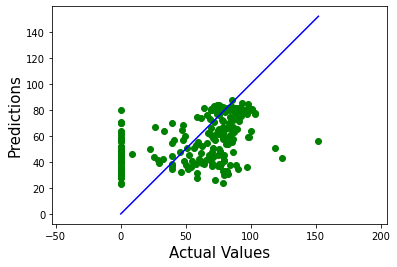

In [23]:
qbract2 = new_nflqb_train['nfl-qbr']
qbrpred2 = new_nflqb_train['Predictions']

plt.scatter(qbract2, qbrpred2, c='green')

p1 = max(max(qbrpred2), max(qbract2))
p2 = min(min(qbrpred2), min(qbract2))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('Actual Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()

Let's visualize the coefficients in a feature coefficients chart as well to compare coefficients and see which features may be most important in this model.

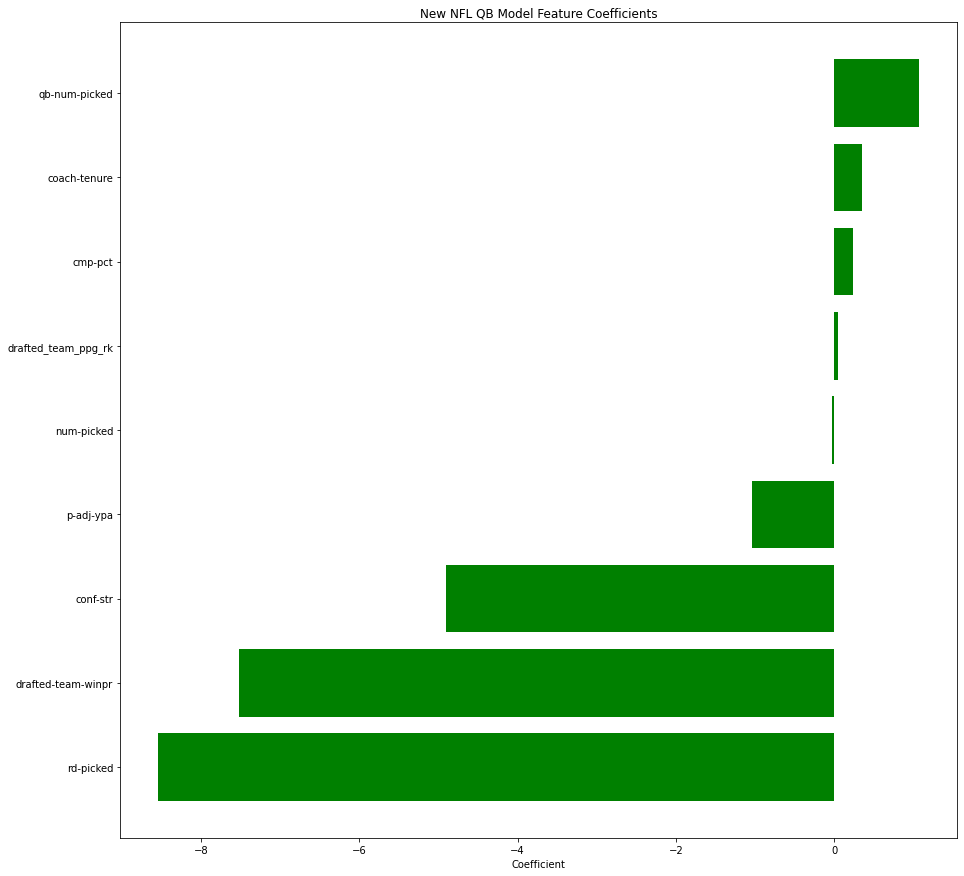

In [27]:
new_features = new_nfl_df.iloc[:, :-1].columns.tolist()

coef_df = pd.DataFrame({'Feature': new_features, 'Coefficient': new_lin_mod.coef_})
coef_df = coef_df.sort_values('Coefficient')
plt.figure(figsize=(15,15))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color = 'green')
plt.xlabel('Coefficient')
plt.title('New NFL QB Model Feature Coefficients')
plt.show()

Based on the plot above, we can see that qb-num-picked, coach-tenure, cmp-pct, drafted_team_ppg_rk, and num_picked area all positive coefficients, which means that these features have a direct relationship on NFL QBR. It is interesting to see however, that passing yards adjusted and round picked have an inverse relationship with NFL QBR, which is seemingly counterintuitive.

# Conclusion

Based on the linear regression analysis conducted above, it does not appear that college statistics nor a combination of college stats and pre-career draft factors predict NFL QBR/success well. There are many reasons for why the analysis above yielded a poor prediction level for NFL success such as:

1. The definition of success can go beyond just NFL QBR, a further analysis should take note of this.
2. Linear regression may not the best model for the dataset.
3. Coefficients were not chosen as scientifically as they could with other methods such as PCA, although from our regression outcomes, it seems that none of the predictors chosen were statistically significant.
4. NFL stats and variables may matter more than college stats and draft day variables.
5. There is heavy skew in this dataset of QBs with a QBR of 0, removing these data points may affect how our model performs.

In a further analysis of this dataset, it would be fruitful to merge other data that captures advanced statistics and other well-known determinants of success as well as increasing the amount of data we have for our training and testing data.